# Feature Engineering: Portfolio Concentration Features and Risk Label

In [58]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import time
import os

## Configuration

In [35]:
PROCESSED_DATA_DIR = "../../data/processed"

## Load Preprocessing Outputs

In [37]:
# Load the cleaned, forward-fill-corrected inputs produced by preprocessing.ipynb
equity_prices = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "equity_close_prices_clean.csv"), index_col=0, parse_dates=True)
df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "cleaned_holdings.csv"), dtype={"cusip": str})
mapping = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "cusip_ticker_sector_mapping_final.csv"), dtype={"cusip": str})

print(f"Equity prices: {equity_prices.shape}")
print(f"Holdings: {df.shape}")
print(f"Mapping: {mapping.shape}")

df.head()

Equity prices: (755, 3451)
Holdings: (1630738, 15)
Mapping: (41065, 4)


,cusip,cik,2015-03,2015-06,2015-09,2015-12,2016-03,2016-06,2016-09,2016-12,2017-03,2017-06,2017-09,stock,institution
0,000000008,1483232,0.00,0.00,0.00,0.00,"70,238.00","70,238.00","70,238.00","70,238.00","70,238.00","70,238.00","70,238.00",VANGUARD FTSE PACIFIC ETF,"TIEDEMANN WEALTH MANAGEMENT, LLC"
1,000000018,1177206,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"980,032.00","980,032.00","980,032.00","980,032.00",Cencosud Sa,LOS ANGELES CAPITAL MANAGEMENT & EQUITY RESEAR...
2,000003128,1541743,0.00,"90,550.00","119,810.00","119,810.00","119,810.00","119,810.00","119,810.00","119,810.00","119,810.00","119,810.00","119,810.00",ABERDEEN ASSET MANAGEMENT,"Copeland Capital Management, LLC"
3,000003638,1606588,0.00,0.00,0.00,0.00,0.00,"34,564.00","34,564.00","34,564.00","34,564.00","34,564.00","34,564.00",ISHARES TR MSCI EAFE,"One Capital Management, LLC"
4,00000C105,1226886,0.00,0.00,0.00,0.00,0.00,0.00,"661,967.00","661,967.00","661,967.00","661,967.00","661,967.00",CITIZENS FINANCIAL GROUP,ALPINE MANAGEMENT & RESEARCH LLC


## Source Industry Sector

`security_type` (from preprocessing) classifies instrument type, not industry. Industry sector is sourced here via `yfinance` ticker metadata. This step is checkpointed: if `sector_mapping.csv` already exists, it is loaded directly rather than re-querying the API.

In [ ]:
def fetch_sector_info(ticker_list, checkpoint_path=None, checkpoint_every=100, max_retries=2):
    results = {}
    total = len(ticker_list)

    for i, ticker in enumerate(ticker_list):
        sector, industry = None, None
        for attempt in range(max_retries):
            try:
                info = yf.Ticker(ticker).info
                sector = info.get("sector") or None
                industry = info.get("industry") or None
                break
            except Exception:
                time.sleep(2)
        results[ticker] = {"sector": sector, "industry": industry}

        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1} / {total}")
        if checkpoint_path and (i + 1) % checkpoint_every == 0:
            pd.DataFrame.from_dict(results, orient="index").reset_index().rename(
                columns={"index": "ticker"}).to_csv(checkpoint_path, index=False)

    return results

(755, 3451)
Tickers to source sector data for: 3451


In [41]:
sector_path = os.path.join(PROCESSED_DATA_DIR, "sector_mapping.csv")

if os.path.exists(sector_path):
    sector_df = pd.read_csv(sector_path)
else:
    sector_results = fetch_sector_info(
        equity_prices.columns.tolist(),
        checkpoint_path=os.path.join(PROCESSED_DATA_DIR, "sector_mapping_checkpoint.csv")
    )
    sector_df = pd.DataFrame.from_dict(sector_results, orient="index").reset_index().rename(columns={"index": "ticker"})
    sector_df.to_csv(sector_path, index=False)

print(f"Sector data: {sector_df.shape}")
print(f"Missing sector: {sector_df['sector'].isna().sum()} / {len(sector_df)}")

Sector data: (3451, 3)
Missing sector: 33 / 3451


## Merge Holdings, Mapping, and Sector Data

Holdings are joined to ticker and security type (via CUSIP), then to sector, and restricted to genuine equity holdings with usable price data.

In [50]:
df_merged = df.merge(mapping[["cusip", "ticker", "security_type"]], on="cusip", how="left")

equity_security_types = ["Common Stock", "Depositary Receipt", "REIT", "Preferred Stock"]
df_equity = df_merged[df_merged["security_type"].isin(equity_security_types)].copy()

df_equity = df_equity.merge(sector_df[["ticker", "sector", "industry"]], on="ticker", how="left")

usable_tickers = set(equity_prices.columns)
df_equity = df_equity[df_equity["ticker"].isin(usable_tickers)].copy()

print(f"After equity-type filter: {len(df_equity)}")
print(f"After usable-ticker filter: {len(df_equity)}")
print(f"Missing sector: {df_equity['sector'].isna().sum()} / {len(df_equity)}")

df_equity.head()

After equity-type filter: 741422
After usable-ticker filter: 741422
Missing sector: 6311 / 741422


,cusip,cik,2015-03,2015-06,2015-09,2015-12,2016-03,2016-06,2016-09,2016-12,2017-03,2017-06,2017-09,stock,institution,ticker,security_type,sector,industry
1,000304105,714142,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,AAC TECHNOLOGIES HLDGS INC,TEACHERS RETIREMENT SYSTEM OF THE STATE OF KEN...,AACAY,Depositary Receipt,Technology,Communication Equipment
2,000304105,820027,0.00,0.00,0.00,0.00,0.00,"3,084.00","2,662.00","2,492.00","2,260.00","2,260.00","2,260.00",AAC TECHNOLOGIES H-UNSPON AD,AMERICAN EXPRESS FINANCIAL ADVISORS,AACAY,Depositary Receipt,Technology,Communication Equipment
3,000304105,883782,0.00,0.00,0.00,0.00,0.00,85.00,71.00,"4,641.00",21.00,21.00,21.00,AAC TECHNOLOGIES HLDGS INC,FULTON BANK,AACAY,Depositary Receipt,Technology,Communication Equipment
4,000304105,932859,0.00,"13,207.00","14,285.00","14,285.00","17,385.00","28,309.00","26,919.00","26,539.00","26,093.00","29,879.00","31,817.00",AAC ACOUSTIC TECHNOLOG ADR,PARAMETRIC PORTFOLIO ASSOCIATES,AACAY,Depositary Receipt,Technology,Communication Equipment
5,000304105,944234,0.00,0.00,0.00,0.00,0.00,"189,282.00","188,244.00","335,136.00","152,263.00","152,263.00","152,263.00",AAC TECHNOLOGIES HOLDINGS IN,RENAISSANCE INVESTMENT MANAGEMENT,AACAY,Depositary Receipt,Technology,Communication Equipment


## Reshape to Long Format and Compute Dollar Values

Wide (one column per quarter) is reshaped to long (one row per institution-holding-quarter), and each holding's dollar value is computed using the closest available trading price on or before each quarter-end.

In [51]:
quarter_cols = ["2015-03", "2015-06", "2015-09", "2015-12",
                 "2016-03", "2016-06", "2016-09", "2016-12",
                 "2017-03", "2017-06", "2017-09"]

quarter_end_dates = {
    "2015-03": "2015-03-31", "2015-06": "2015-06-30", "2015-09": "2015-09-30", "2015-12": "2015-12-31",
    "2016-03": "2016-03-31", "2016-06": "2016-06-30", "2016-09": "2016-09-30", "2016-12": "2016-12-31",
    "2017-03": "2017-03-31", "2017-06": "2017-06-30", "2017-09": "2017-09-30"
}

df_long = df_equity.melt(
    id_vars=["cusip", "cik", "institution", "stock", "ticker", "security_type", "sector", "industry"],
    value_vars=quarter_cols,
    var_name="quarter",
    value_name="shares"
)
df_long = df_long[df_long["shares"] > 0].copy()

def get_price_on_or_before(price_series, date):
    available = price_series.index[price_series.index <= date]
    return price_series.loc[available.max()] if len(available) > 0 else None

price_lookup = {}
for q_label, q_date in quarter_end_dates.items():
    q_date = pd.Timestamp(q_date)
    available_dates = equity_prices.index[equity_prices.index <= q_date]
    price_lookup[q_label] = equity_prices.loc[available_dates.max()] if len(available_dates) > 0 else pd.Series(dtype=float)

df_long["price"] = df_long.apply(lambda row: price_lookup[row["quarter"]].get(row["ticker"], None), axis=1)
df_long["dollar_value"] = df_long["shares"] * df_long["price"]

df_valid = df_long[df_long["price"].notna()].copy()
print(f"Long-format rows: {len(df_long)}")
print(f"Rows with valid price: {len(df_valid)}")

df_valid.head()

Long-format rows: 5375433
Rows with valid price: 5362478


,cusip,cik,institution,stock,ticker,security_type,sector,industry,quarter,shares,price,dollar_value
173,000360206,1558481,Arizona State Retirement System,AAON INC,AAON,Common Stock,Industrials,Building Products & Equipment,2015-03,"29,275.00",15.18,"444,302.07"
245,000361105,867262,GW CAPITAL INC,AAR CORP,AIR,Common Stock,Industrials,Aerospace & Defense,2015-03,"729,591.00",29.23,"21,324,795.15"
375,000361105,1511566,Spot Trading L.L.C,AAR CORP,AIR,Common Stock,Industrials,Aerospace & Defense,2015-03,"17,100.00",29.23,"499,806.05"
389,000361105,1558481,Arizona State Retirement System,AAR CORP,AIR,Common Stock,Industrials,Aerospace & Defense,2015-03,"26,523.00",29.23,"775,225.49"
530,000375204,1037763,GRAVER BOKHOF GOODWILL & SULLIVAN L P/IL,ABB LTD,ABBNY,Depositary Receipt,Industrials,Electrical Equipment & Parts,2015-03,"1,450.00",14.08,"20,413.31"


## Compute Portfolio Concentration Features

For each institution-quarter: HHI (concentration across holdings), top-holding percentage, number of distinct holdings, and sector HHI (concentration across sectors).

In [44]:
def compute_portfolio_features(group):
    total_value = group["dollar_value"].sum()
    weights = group["dollar_value"] / total_value

    sector_values = group.groupby("sector")["dollar_value"].sum()
    sector_weights = sector_values / total_value

    return pd.Series({
        "total_value": total_value,
        "hhi": (weights ** 2).sum(),
        "top_holding_pct": weights.max(),
        "num_holdings": len(group),
        "sector_hhi": (sector_weights ** 2).sum()
    })

portfolio_features = df_valid.groupby(["cik", "institution", "quarter"]).apply(
    compute_portfolio_features, include_groups=False
).reset_index()

portfolio_features.to_csv(os.path.join(PROCESSED_DATA_DIR, "portfolio_features.csv"), index=False)
print(f"Institution-quarter portfolios: {len(portfolio_features)}")

Institution-quarter portfolios: 22855


## Load Benchmark Data

`sp500_benchmark.csv` uses a two-level column header (as saved by `yfinance`); this is handled explicitly on load.

In [53]:
benchmark = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "sp500_benchmark.csv"), header=[0, 1], index_col=0)
benchmark.index = pd.to_datetime(benchmark.index)
benchmark_close = benchmark[("Close", "^GSPC")]

benchmark.head()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2015-01-02,"2,058.20","2,072.36","2,046.04","2,058.90",2708700000
2015-01-05,"2,020.58","2,054.44","2,017.34","2,054.44",3799120000
2015-01-06,"2,002.61","2,030.25","1,992.44","2,022.15",4460110000
2015-01-07,"2,025.90","2,029.61","2,005.55","2,005.55",3805480000
2015-01-08,"2,062.14","2,064.08","2,030.61","2,030.61",3934010000


## Construct the Risk Label

For each institution-quarter, the concentration-weighted excess return over the following quarter, relative to the S&P 500, is computed:

`weighted_excess_return = Σ (holding_weight × (holding_forward_return − benchmark_forward_return))`

An initial version of this calculation, without explicit NaN handling, produced 1,610 incorrect NaN labels out of 20,244 (7.9%). The cause is demonstrated below before the corrected version is applied.

In [52]:
# an initial (unfixed) run of the label-construction loop below produced 1,610 NaN labels out of 20,244 (7.9%). Tracing one case (CIK 939835, an 83-holding portfolio with no zero or missing dollar values) found the cause:
# a single ticker returning NaN, not None, from the price lookup.

for ticker in ["TEV"]:
    fwd = compute_forward_return(ticker, pd.Timestamp("2015-03-31"), pd.Timestamp("2015-06-30"))
    print(f"{ticker}: forward return = {fwd} ({'NaN' if pd.isna(fwd) else 'valid'})")

TEV: forward return = None (NaN)


In [46]:
quarter_order = quarter_cols
next_quarter_map = {quarter_order[i]: quarter_order[i + 1] for i in range(len(quarter_order) - 1)}

def compute_forward_return(ticker, current_q_date, next_q_date):
    try:
        price_now = get_price_on_or_before(equity_prices[ticker], current_q_date)
        price_next = get_price_on_or_before(equity_prices[ticker], next_q_date)
        if price_now is None or price_next is None or pd.isna(price_now) or pd.isna(price_next) or price_now == 0:
            return None
        return (price_next - price_now) / price_now
    except KeyError:
        return None

def benchmark_return(current_q_date, next_q_date):
    price_now = get_price_on_or_before(benchmark_close, current_q_date)
    price_next = get_price_on_or_before(benchmark_close, next_q_date)
    if price_now is None or price_next is None or pd.isna(price_now) or pd.isna(price_next):
        return None
    return (price_next - price_now) / price_now

label_rows = []
for quarter in quarter_order[:-1]:
    next_quarter = next_quarter_map[quarter]
    current_q_date = pd.Timestamp(quarter_end_dates[quarter])
    next_q_date = pd.Timestamp(quarter_end_dates[next_quarter])

    bench_ret = benchmark_return(current_q_date, next_q_date)
    if bench_ret is None:
        continue

    quarter_holdings = df_valid[df_valid["quarter"] == quarter]
    for (cik, institution), group in quarter_holdings.groupby(["cik", "institution"]):
        total_value = group["dollar_value"].sum()
        weighted_excess_return, any_valid = 0, False

        for _, row in group.iterrows():
            fwd_ret = compute_forward_return(row["ticker"], current_q_date, next_q_date)
            if fwd_ret is not None:
                weighted_excess_return += (row["dollar_value"] / total_value) * (fwd_ret - bench_ret)
                any_valid = True

        label_rows.append({
            "cik": cik, "institution": institution, "quarter": quarter,
            "weighted_excess_return": weighted_excess_return if any_valid else None
        })

label_df = pd.DataFrame(label_rows)
print(f"Label rows: {len(label_df)}, missing: {label_df['weighted_excess_return'].isna().sum()}")

Label rows: 20244, missing: 0


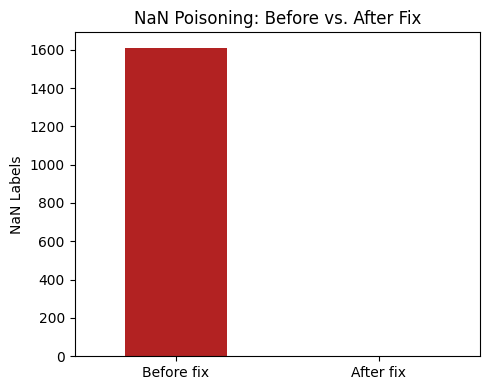

In [60]:
fig, ax = plt.subplots(figsize=(5, 4))
pd.Series({"Before fix": 1610, "After fix": 0}).plot(kind="bar", ax=ax, color=["firebrick", "steelblue"])
ax.set_ylabel("NaN Labels")
ax.set_title("NaN Poisoning: Before vs. After Fix")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "..", "..", "reports", "nan_fix_impact.png"), dpi=100)
plt.show()

1,610 of 20,244 labels (7.9%) were incorrectly NaN before explicit isna() checks were added; the fix eliminates this entirely.

## Select the Loss Threshold

A -15% threshold (the problem statement's initial estimate) was checked empirically and found to flag only 0.7% of portfolios, too rare for meaningful model training. Several thresholds were tested before selecting a final value.

In [47]:
for threshold in [-0.15, -0.12, -0.10, -0.07, -0.05]:
    proportion = (label_df["weighted_excess_return"] < threshold).mean()
    count = (label_df["weighted_excess_return"] < threshold).sum()
    print(f"Threshold {threshold:.0%}: {count} positive cases ({proportion:.1%})")

Threshold -15%: 134 positive cases (0.7%)
Threshold -12%: 189 positive cases (0.9%)
Threshold -10%: 283 positive cases (1.4%)
Threshold -7%: 516 positive cases (2.5%)
Threshold -5%: 854 positive cases (4.2%)


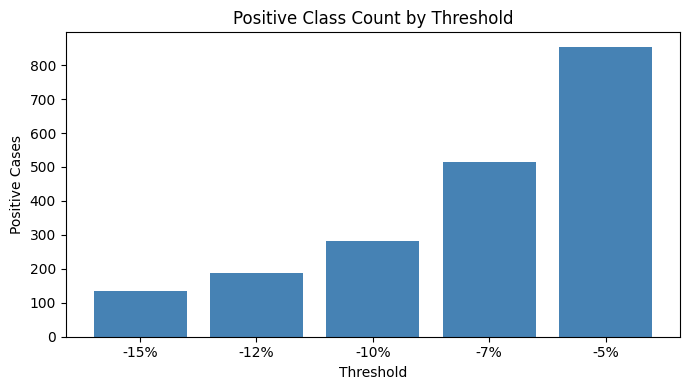

In [59]:
thresholds = [-0.15, -0.12, -0.10, -0.07, -0.05]
counts = [(label_df["weighted_excess_return"] < t).sum() for t in thresholds]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([f"{t:.0%}" for t in thresholds], counts, color="steelblue")
ax.set_xlabel("Threshold")
ax.set_ylabel("Positive Cases")
ax.set_title("Positive Class Count by Threshold")
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "..", "..", "reports", "threshold_selection.png"), dpi=100)
plt.show()

Positive case counts rise sharply as the threshold moves from -15% toward -5%, illustrating why -15% was too rare to support model training.

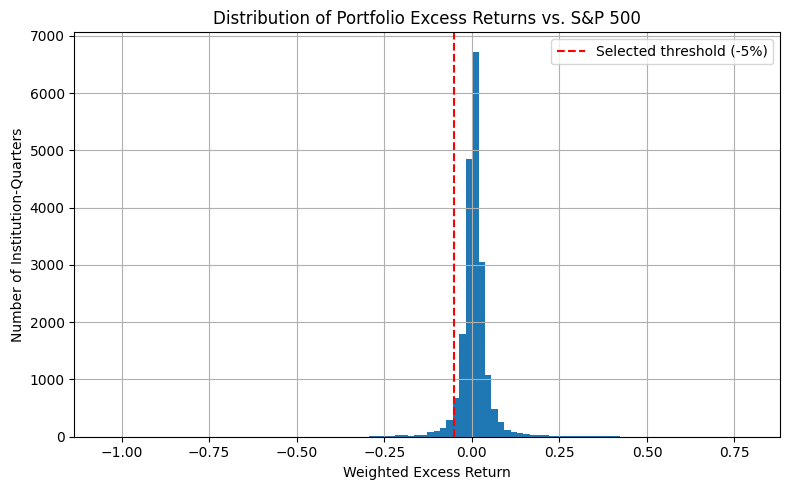

In [56]:
fig, ax = plt.subplots(figsize=(8, 5))
label_df["weighted_excess_return"].hist(bins=100, ax=ax)
ax.axvline(loss_threshold, color="red", linestyle="--", label=f"Selected threshold ({loss_threshold:.0%})")
ax.set_xlabel("Weighted Excess Return")
ax.set_ylabel("Number of Institution-Quarters")
ax.set_title("Distribution of Portfolio Excess Returns vs. S&P 500")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "..", "..", "reports", "excess_return_distribution.png"), dpi=100)
plt.show()

The distribution is centred near zero, with a long left tail. The selected -5% threshold sits well within this tail, flagging genuinely unusual underperformance rather than ordinary quarterly variation.

## Finalise Label and Save Modelling Table

-5% is selected as the final threshold (4.2% positive class), balancing a meaningful underperformance definition against having enough positive examples to train on.

In [48]:
loss_threshold = -0.05
label_df["label"] = (label_df["weighted_excess_return"] < loss_threshold).astype(int)

model_data = portfolio_features.merge(
    label_df[["cik", "quarter", "weighted_excess_return", "label"]],
    on=["cik", "quarter"], how="inner"
)

model_data.to_csv(os.path.join(PROCESSED_DATA_DIR, "model_features.csv"), index=False)
print(f"Final modelling table: {model_data.shape}")
print(model_data["label"].value_counts())

Final modelling table: (20244, 10)
label
0    19390
1      854
Name: count, dtype: int64


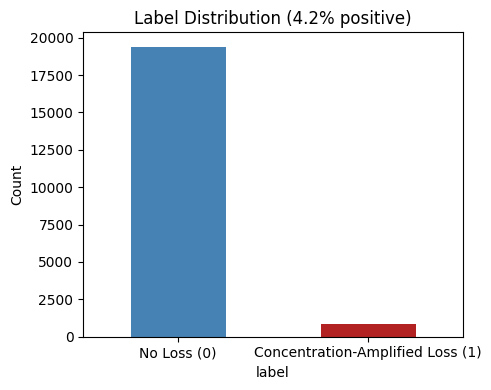

In [55]:
fig, ax = plt.subplots(figsize=(5, 4))
model_data["label"].value_counts().plot(kind="bar", ax=ax, color=["steelblue", "firebrick"])
ax.set_xticklabels(["No Loss (0)", "Concentration-Amplified Loss (1)"], rotation=0)
ax.set_ylabel("Count")
ax.set_title(f"Label Distribution ({model_data['label'].mean():.1%} positive)")
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "..", "..", "reports", "label_balance.png"), dpi=100)
plt.show()

The label is heavily imbalanced (4.2% positive), confirming that accuracy alone would be a misleading evaluation metric for the models built on this data.

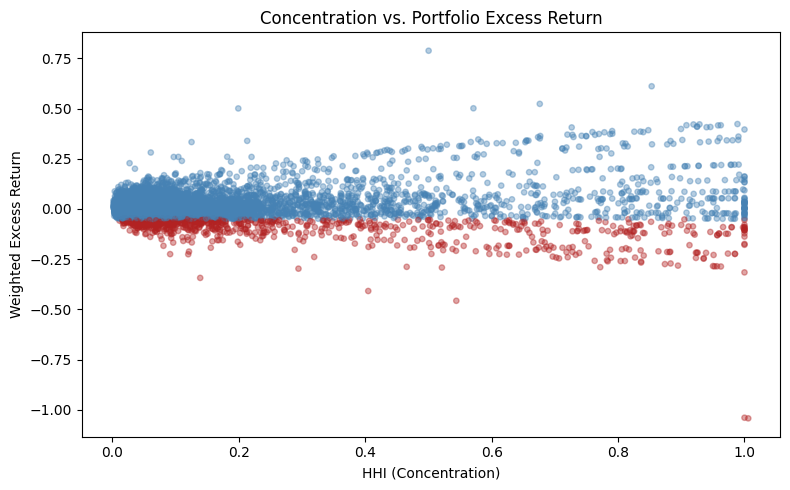

In [57]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = model_data["label"].map({0: "steelblue", 1: "firebrick"})
ax.scatter(model_data["hhi"], model_data["weighted_excess_return"], c=colors, alpha=0.4, s=15)
ax.set_xlabel("HHI (Concentration)")
ax.set_ylabel("Weighted Excess Return")
ax.set_title("Concentration vs. Portfolio Excess Return")
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "..", "..", "reports", "hhi_vs_excess_return.png"), dpi=100)
plt.show()

Red (loss) points are visibly concentrated toward higher HHI values, a first visual indication that concentration is genuinely associated with the risk this study aims to predict.